## **Impact de l’enrichissement des données transactionnelles bancaires par des scores de risque de réputation IP sur la détection de fraude par Machine Learning** 




## Problème et Objectif du projet

L’amélioration des performances des systèmes de détection de fraude bancaire constitue aujourd’hui un enjeu majeur pour les institutions financières. 
    Face à l’évolution des techniques de fraude numérique et à l’augmentation continue du volume des transactions électroniques, toute approche permettant d’améliorer l’efficacité des modèles de détection représente un intérêt stratégique pour les acteurs bancaires.
Dans ce contexte, l’objectif de ce projet est d’évaluer l’impact de l’enrichissement des données transactionnelles par des scores externes de réputation IP sur les performances des modèles de Machine Learning appliqués à la détection de fraude bancaire.

## Dataset

Après analyse du dataset retenu pour cette étude, il apparaît que celui-ci contient des données hétérogènes liées à la détection de fraude bancaire et e-commerce. Le dataset repose sur des transactions historiques contenant plusieurs variables transactionnelles classiques telles que le montant des opérations, la fréquence des transactions, le mode de paiement ou encore les informations temporelles. Il contient également la variable cible is_fraud, indiquant si une transaction est légitime ou frauduleuse.
Parmi les variables disponibles figure notamment ip_risk_score, représentant un score de risque associé à l’adresse IP utilisée lors de la transaction. Cette variable permet d’ajouter une dimension comportementale et réseau aux données transactionnelles classiques en intégrant des signaux liés à l’utilisation de VPN, de proxies anonymes, de centres de données ou d’autres activités réseau potentiellement suspectes.
La documentation officielle du dataset mentionne explicitement l’intégration de fonctionnalités de type IP risk scores, représentant le niveau de risque associé à une adresse IP utilisée lors d’une transaction bancaire en ligne. 
Dans cette expérimentation, la variable ip_risk_score est utilisée comme mécanisme d’enrichissement externe afin d’évaluer son impact sur les performances des modèles de Machine Learning dans la détection de fraude bancaire.


## Importation des Bibliothèsques nécessaires

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import plotly.express as px
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, precision_recall_curve
np.random.seed(42)
import joblib
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix


 ## Exploration et préparation de données

In [4]:
# Lecture du dataSet
df2=pd.read_csv("data/ecom_fraud.csv") 

In [5]:
# Pour  afficher l'ensemble des Colonnes
pd.set_option('display.max_columns', None)

In [6]:
# Afficher les 5 premières lignes
df2.head()

,transaction_id,user_id,timestamp_utc,amount_aed,currency,payment_method,device_type,browser,merchant_category,items_count,avg_item_price,shipping_city,billing_city,shipping_billing_match,ip_address,ip_risk_score,card_present,bin_country,card_age_days,card_country_match,email_domain,user_prev_chargebacks,user_is_high_risk,user_account_age_days,transactions_last_24h,transactions_last_1h,local_hour,odd_hour,is_fraud,fraud_flag_ip,fraud_flag_mismatch,fraud_flag_velocity,fraud_flag_new_account,fraud_flag_prev_cb,fraud_flag_odd_hour,data_source
0,500086758,1000466,2024-01-01T00:02:03Z,71.47,AED,card,desktop,Chrome,Pharmacy,3,23.82,Dubai,Dubai,1,144.108.182.242,35.3,0,AE,85,1,gmail.com,0,0,365,0,0,4,1,0,0,0,0,0,0,1,synthetic:ecom-fraud-uae-v1
1,500060464,1002828,2024-01-01T00:03:11Z,70.25,AED,card,mobile,Chrome,Groceries,1,70.25,Abu Dhabi,Abu Dhabi,1,104.37.234.72,30.2,0,SA,123,0,outlook.com,0,0,-192,0,0,4,1,0,0,0,0,1,0,1,synthetic:ecom-fraud-uae-v1
2,500039909,1010349,2024-01-01T00:04:10Z,116.25,AED,bank_transfer,desktop,Chrome,Beauty,2,58.12,Cairo,Cairo,1,89.169.143.66,32.7,0,PK,542,0,gmail.com,0,0,1744,0,0,4,1,0,0,0,0,0,0,1,synthetic:ecom-fraud-uae-v1
3,500074412,1015360,2024-01-01T00:05:14Z,99.41,AED,apple_pay,mobile,Safari,Toys,2,49.70,Mumbai,Mumbai,1,37.54.200.109,30.3,0,EG,981,0,outlook.com,0,0,102,0,0,4,1,0,0,0,0,0,0,1,synthetic:ecom-fraud-uae-v1
4,500038110,1022253,2024-01-01T00:11:03Z,529.40,AED,card,desktop,Safari,Travel,2,264.70,Dubai,Dubai,1,18.172.52.222,18.5,0,AE,515,1,gmail.com,1,1,-59,0,0,4,1,0,0,0,0,1,1,1,synthetic:ecom-fraud-uae-v1


In [5]:
# Obtenir un résumé technique du dataset.
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   transaction_id          100000 non-null  int64  
 1   user_id                 100000 non-null  int64  
 2   timestamp_utc           100000 non-null  object 
 3   amount_aed              100000 non-null  float64
 4   currency                100000 non-null  object 
 5   payment_method          100000 non-null  object 
 6   device_type             100000 non-null  object 
 7   browser                 100000 non-null  object 
 8   merchant_category       100000 non-null  object 
 9   items_count             100000 non-null  int64  
 10  avg_item_price          100000 non-null  float64
 11  shipping_city           100000 non-null  object 
 12  billing_city            100000 non-null  object 
 13  shipping_billing_match  100000 non-null  int64  
 14  ip_address           

** Le dataset contient 100000 transactions, ce qui constitue un volume de données adapté à l’entraînement et à l’évaluation de modèles de Machine Learning. **

In [8]:

# Pour obtenir des statistiques descriptives sur les variables numériques du dataset.
df2.describe()

,transaction_id,user_id,amount_aed,items_count,avg_item_price,shipping_billing_match,ip_risk_score,card_present,card_age_days,card_country_match,user_prev_chargebacks,user_is_high_risk,user_account_age_days,transactions_last_24h,transactions_last_1h,local_hour,odd_hour,is_fraud,fraud_flag_ip,fraud_flag_mismatch,fraud_flag_velocity,fraud_flag_new_account,fraud_flag_prev_cb,fraud_flag_odd_hour
count,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.0,100000.000000,100000.000000,100000.000000
mean,5.000500e+08,1.014983e+06,162.863922,2.195740,94.841077,0.926650,39.816773,0.030300,521.341500,0.60054,0.030340,0.048710,733.422820,0.009230,0.000410,11.485260,0.250410,0.082110,0.035520,0.03155,0.0,0.180170,0.029810,0.250410
std,2.886766e+04,8.658202e+03,401.181135,1.096813,252.178620,0.260711,16.479326,0.171412,373.760854,0.48979,0.174585,0.215262,633.678787,0.096046,0.020244,6.921737,0.433251,0.274534,0.185091,0.17480,0.0,0.384331,0.170064,0.433251
min,5.000000e+08,1.000000e+06,1.260000,1.000000,0.360000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,-365.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000
25%,5.000250e+08,1.007487e+06,41.370000,1.000000,19.610000,1.000000,28.100000,0.000000,219.000000,0.00000,0.000000,0.000000,186.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000
50%,5.000500e+08,1.014957e+06,82.100000,2.000000,42.330000,1.000000,39.200000,0.000000,456.000000,1.00000,0.000000,0.000000,738.000000,0.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000
75%,5.000750e+08,1.022467e+06,164.885000,3.000000,92.850000,1.000000,50.800000,0.000000,758.000000,1.00000,0.000000,0.000000,1278.000000,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,1.000000
max,5.001000e+08,1.029999e+06,28785.920000,9.000000,14392.960000,1.000000,100.000000,1.000000,2728.000000,1.00000,2.000000,1.000000,1825.000000,2.000000,1.000000,23.000000,1.000000,1.000000,1.000000,1.00000,0.0,1.000000,1.000000,1.000000


** L’analyse descriptive montre que l’ensemble des variables contient 100000 observations non nulles, ce qui indique l’absence de valeurs manquantes dans le dataset. 

L’analyse de la variable amount_aed met en évidence une forte dispersion des montants transactionnels.
Le montant moyen des transactions est de 162.86 AED, tandis que la médiane est de 82.10 AED, ce qui indique une asymétrie importante dans la distribution des valeurs.
De plus, l’écart-type élevé (401.18 AED) ainsi que la présence de valeurs extrêmes atteignant 28785.92 AED traduisent une variabilité significative des montants observés.
Cette dispersion peut refléter des comportements transactionnels atypiques ou anormaux, souvent associés aux scénarios de fraude financière. **

In [9]:

# Pour voir toutes les variables disponibles, sélectionner les features, supprimer certaines colonnes et vérifier les transformations.
df2.columns

Index(['transaction_id', 'user_id', 'timestamp_utc', 'amount_aed', 'currency',
       'payment_method', 'device_type', 'browser', 'merchant_category',
       'items_count', 'avg_item_price', 'shipping_city', 'billing_city',
       'shipping_billing_match', 'ip_address', 'ip_risk_score', 'card_present',
       'bin_country', 'card_age_days', 'card_country_match', 'email_domain',
       'user_prev_chargebacks', 'user_is_high_risk', 'user_account_age_days',
       'transactions_last_24h', 'transactions_last_1h', 'local_hour',
       'odd_hour', 'is_fraud', 'fraud_flag_ip', 'fraud_flag_mismatch',
       'fraud_flag_velocity', 'fraud_flag_new_account', 'fraud_flag_prev_cb',
       'fraud_flag_odd_hour', 'data_source'],
      dtype='object')

In [10]:
# Pour détecter les valeurs manquantes dans le dataset.

df2.isnull().sum()

transaction_id            0
user_id                   0
timestamp_utc             0
amount_aed                0
currency                  0
payment_method            0
device_type               0
browser                   0
merchant_category         0
items_count               0
avg_item_price            0
shipping_city             0
billing_city              0
shipping_billing_match    0
ip_address                0
ip_risk_score             0
card_present              0
bin_country               0
card_age_days             0
card_country_match        0
email_domain              0
user_prev_chargebacks     0
user_is_high_risk         0
user_account_age_days     0
transactions_last_24h     0
transactions_last_1h      0
local_hour                0
odd_hour                  0
is_fraud                  0
fraud_flag_ip             0
fraud_flag_mismatch       0
fraud_flag_velocity       0
fraud_flag_new_account    0
fraud_flag_prev_cb        0
fraud_flag_odd_hour       0
data_source         

L’analyse des valeurs manquantes montre que l’ensemble des variables du dataset est complet et ne présente aucune donnée absente.

<Axes: xlabel='is_fraud', ylabel='count'>

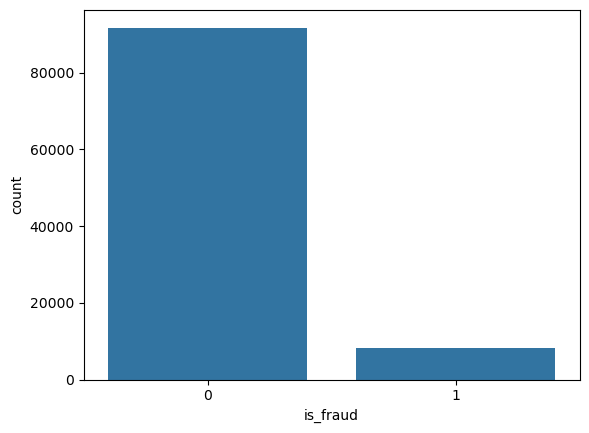

In [12]:
# Analyser la distribution de la variable cible
df2['is_fraud'].value_counts()
# Afficher le graphique de distribution de la variable cible
sns.countplot(x='is_fraud', data=df2)



Dans ce graphique :
- la barre correspondant à la valeur 0 représente le nombre de transactions normales (non frauduleuses),
- la barre correspondant à la valeur 1 représente le nombre de transactions frauduleuses.
  
L’analyse de la variable cible met en évidence un déséquilibre des classes, les transactions frauduleuses représentant une proportion significativement plus faible que les transactions légitimes.

In [13]:
# calculer les proportions de la classe is_fraud
df2['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.91789
1    0.08211
Name: proportion, dtype: float64

 ## Sélection des variables et définition des caractéristiques

Une étape de sélection des variables a été réalisée afin de conserver uniquement les attributs les plus pertinents pour la détection de fraude bancaire ainsi que pour l évaluation de l impact de l’enrichissement par score de risque IP.
L’objectif de cette étape n’était pas d’exploiter exhaustivement l’ensemble des variables disponibles dans le dataset, mais de retenir les caractéristiques les plus cohérentes avec la problématique étudiée et l’hypothèse scientifique du projet.
Les variables sélectionnées couvrent principalement :
- les caractéristiques transactionnelles,
- les dimensions comportementales,
- les signaux temporels,
- ainsi que les mécanismes d’enrichissement externe basés sur la réputation IP.

| Variable | Type | Rôle antifraude |
|---|---|---|
| timestamp_utc | Temporelle | Analyse temporelle des transactions et détection des comportements inhabituels |
| amount_aed | Transactionnelle | Détection des montants atypiques et des anomalies financières |
| items_count | Transactionnelle | Analyse des paniers atypiques et des achats massifs |
| avg_item_price | Transactionnelle | Vérification de la cohérence du panier d’achat et détection des comportements inhabituels |
| ip_risk_score | Enrichissement externe | Évaluation du niveau de risque réseau associé à l’adresse IP utilisée lors de la transaction |
| is_fraud | Variable cible | Indique si la transaction est légitime (0) ou frauduleuse (1) |
| transactions_last_24h | Temporelle | Analyse de la fréquence transactionnelle | 
| transactions_last_1h | Temporelle | Détection des activités rapides ou automatisées |
|payment_method|Comportementale|Analyse des méthodes de paiement utilisées et identification des moyens de paiement associés à des comportements potentiellement frauduleux|

In [14]:
selected_columns = [
    'timestamp_utc',
    'amount_aed',
     'items_count',
    'avg_item_price',
    'ip_risk_score',
    'is_fraud',
    'transactions_last_24h',
    'transactions_last_1h',
    'payment_method'
    
    
]
df_selected = df2[selected_columns].copy()


## Mise à l'échelle et transformation des données

Une étape de mise à l’échelle des données numériques a été réalisée car les variables utilisées présentent des amplitudes très différentes. Par exemple, amount_aed peut atteindre plusieurs milliers d’unités alors que items_count ou transactions_last_24h prennent des valeurs beaucoup plus faibles.
Sans normalisation, les variables ayant les plus grandes valeurs pourraient influencer de manière disproportionnée l’apprentissage des modèles. Le scaling permet ainsi d’harmoniser les échelles des variables numériques et d’améliorer les performances des algorithmes sensibles aux différences d’amplitude.

In [15]:
# ======================================
# Création du dataset sélectionné
# ======================================

selected_columns = [
    'timestamp_utc',
    'transactions_last_24h',
    'transactions_last_1h',
    'amount_aed',
    'payment_method',
    'items_count',
    'avg_item_price',
    'ip_risk_score',
    'is_fraud'
]

df_selected = df2[selected_columns].copy()


# ======================================
# Transformation du timestamp
# ======================================

df_selected['timestamp_utc'] = pd.to_datetime(
    df_selected['timestamp_utc']
)

df_selected['hour'] = (
    df_selected['timestamp_utc'].dt.hour
)

df_selected['day_of_week'] = (
    df_selected['timestamp_utc'].dt.dayofweek
)


# ======================================
# Suppression du timestamp brut
# ======================================

df_without_timestamp = df_selected.drop(
    columns=['timestamp_utc']
)


# ======================================
# Encodage catégoriel
# ======================================

df_without_timestamp = pd.get_dummies(
    df_without_timestamp,
    columns=['payment_method'],
    drop_first=True,
    dtype=int
)


# ======================================
# Variables numériques à scaler
# ======================================

numeric_features = [
    'amount_aed',
    'transactions_last_24h',
    'transactions_last_1h',
    'items_count',
    'avg_item_price',
    'ip_risk_score',
    'hour',
    'day_of_week'
]


# ======================================
# Scaling
# ======================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_without_timestamp[numeric_features] = scaler.fit_transform(
    df_without_timestamp[numeric_features]
)


# ======================================
# Vérification finale
# ======================================

df_without_timestamp.head()

,transactions_last_24h,transactions_last_1h,amount_aed,items_count,avg_item_price,ip_risk_score,is_fraud,hour,day_of_week,payment_method_bank_transfer,payment_method_card,payment_method_google_pay,payment_method_paypal
0,-0.0961,-0.020253,-0.227813,0.733274,-0.281631,-0.274089,0,-1.657394,-1.4906,0,1,0,0
1,-0.0961,-0.020253,-0.230854,-1.090201,-0.097515,-0.583569,0,-1.657394,-1.4906,0,1,0,0
2,-0.0961,-0.020253,-0.116192,-0.178463,-0.145616,-0.431863,0,-1.657394,-1.4906,1,0,0,0
3,-0.0961,-0.020253,-0.158169,-0.178463,-0.179005,-0.577501,0,-1.657394,-1.4906,0,0,0,0
4,-0.0961,-0.020253,0.913647,-0.178463,0.673569,-1.293553,0,-1.657394,-1.4906,0,1,0,0


 ## Séparation des variables

In [16]:
# ======================================
# Variables transactionnelles
# ======================================

transactional_features = [
    'transactions_last_24h',
    'transactions_last_1h',
    'amount_aed',
    'items_count',
    'hour',
    'day_of_week',
    'avg_item_price'
]


# ======================================
# Variables de paiement encodées
# ======================================

payment_features = [
    col for col in df_without_timestamp.columns
    if 'payment_method_' in col
]


# ======================================
# Variable externe
# ======================================

external_feature = [
    'ip_risk_score'
]


# ======================================
# Variable cible
# ======================================

target = 'is_fraud'


# ======================================
# Colonnes finales sélectionnées
# ======================================

selected_columns = (
    transactional_features
    + payment_features
    + [target]
)

# ======================================
# Création du dataset final
# ======================================

df_selected = df_without_timestamp[selected_columns]


# ======================================
# Affichage du résultat
# ======================================

df_selected.head()

,transactions_last_24h,transactions_last_1h,amount_aed,items_count,hour,day_of_week,avg_item_price,payment_method_bank_transfer,payment_method_card,payment_method_google_pay,payment_method_paypal,is_fraud
0,-0.0961,-0.020253,-0.227813,0.733274,-1.657394,-1.4906,-0.281631,0,1,0,0,0
1,-0.0961,-0.020253,-0.230854,-1.090201,-1.657394,-1.4906,-0.097515,0,1,0,0,0
2,-0.0961,-0.020253,-0.116192,-0.178463,-1.657394,-1.4906,-0.145616,1,0,0,0,0
3,-0.0961,-0.020253,-0.158169,-0.178463,-1.657394,-1.4906,-0.179005,0,0,0,0,0
4,-0.0961,-0.020253,0.913647,-0.178463,-1.657394,-1.4906,0.673569,0,1,0,0,0


In [17]:
# ======================================
# Séparation des variables explicatives (X)
# et de la variable cible (y)
# ======================================

X = df_selected.drop(columns=['is_fraud'])

y = df_selected['is_fraud']


# ======================================
# Division du dataset
# en jeu d'entraînement et jeu de test
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,      # 30% pour le test
    random_state=42,    # reproductibilité des résultats
    stratify=y          # conservation de la proportion fraude/non fraude
)


# ======================================
# Vérification des dimensions
# ======================================

print("Taille du jeu d'entraînement :", X_train.shape)
print("Taille du jeu de test :", X_test.shape)

print("Taille y_train :", y_train.shape)
print("Taille y_test :", y_test.shape)

Taille du jeu d'entraînement : (70000, 11)
Taille du jeu de test : (30000, 11)
Taille y_train : (70000,)
Taille y_test : (30000,)


## Test du modèle Random Forest

In [18]:
# ======================================
# Test du modèle Random Forest
# ======================================

from sklearn.ensemble import RandomForestClassifier


# ======================================
# Création du modèle
# ======================================

rf_model = RandomForestClassifier(
    n_estimators=100,   # Nombre d’arbres de décision
    max_depth=10,       # Profondeur maximale des arbres
    random_state=42,     # Reproductibilité des résultats
  class_weight='balanced'  # Donner plus d’importance aux transactions frauduleuses
)


## Entraînement du modèle baseline

In [19]:
rf_model.fit(X_train, y_train)


# ======================================
# Confirmation
# ======================================

print("Le modèle Random Forest a été entraîné avec succès.")



Le modèle Random Forest a été entraîné avec succès.


In [41]:
import joblib
# sauvegarder le model
joblib.dump(rf_model, "model_baseline.pkl")

['model_baseline.pkl']

  ## Prédictions

In [21]:
y_pred = rf_model.predict(X_test)
print(y_pred[:10])

[0 1 1 0 0 0 0 0 0 0]


## les probabilités de fraude

In [22]:
# Probabilité d’appartenir à la classe fraude
y_proba = rf_model.predict_proba(X_test)
# Affichage des 10 premières probabilités
print(y_proba[:10])

[[0.55177775 0.44822225]
 [0.47227399 0.52772601]
 [0.49494602 0.50505398]
 [0.51441737 0.48558263]
 [0.51949999 0.48050001]
 [0.50852585 0.49147415]
 [0.52721239 0.47278761]
 [0.50169297 0.49830703]
 [0.51772764 0.48227236]
 [0.52152493 0.47847507]]


Par défaut, les algorithmes de classification de Scikit-Learn utilisent généralement un seuil de décision fixé à 0.5 pour déterminer si une transaction est considérée comme frauduleuse ou non.
une transaction présentant une probabilité de fraude de 0.36 sera classée comme légitime, car le score reste inférieur au seuil de 0.5 ;
une transaction présentant une probabilité de fraude de 0.59 sera classée comme frauduleuse, car le score dépasse le seuil défini.

  ## Mesures d'évaluation

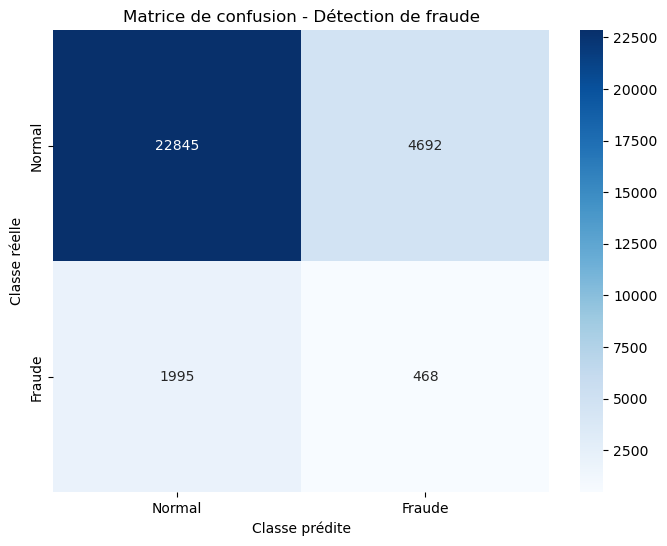

ROC-AUC : 0.5012803207188952
========== Rapport de classification ==========
              precision    recall  f1-score   support

           0       0.92      0.83      0.87     27537
           1       0.09      0.19      0.12      2463

    accuracy                           0.78     30000
   macro avg       0.51      0.51      0.50     30000
weighted avg       0.85      0.78      0.81     30000

========== Métriques principales ==========
Accuracy : 0.7771
Precision : 0.09069767441860466
Recall : 0.1900121802679659
F1-score : 0.12278630460448642
ROC-AUC : 0.5012803207188952


In [23]:

# ======================================
# Affichage de la matrice de confusion
# ======================================
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=['Normal', 'Fraude'],
    yticklabels=['Normal', 'Fraude']
)

plt.xlabel('Classe prédite')

plt.ylabel('Classe réelle')

plt.title('Matrice de confusion - Détection de fraude')

plt.show()

# ======================================
# Calcul des métriques de classification
# ======================================
# Prédictions finales
y_pred = rf_model.predict(X_test)

# Probabilités de fraude
y_prob = rf_model.predict_proba(X_test)[:,1]

# Calcul ROC-AUC
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC :", auc)
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_prob)


# ======================================
# Affichage des résultats
# ======================================

print("========== Rapport de classification ==========")

print(classification_report(y_test, y_pred))


print("========== Métriques principales ==========")

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1-score :", f1)

print("ROC-AUC :", auc)


L’utilisation du rééquilibrage des classes a permis d’améliorer significativement la capacité du modèle à détecter les transactions frauduleuses, comme le montre l’augmentation importante du Recall. En contrepartie, la précision diminue et le nombre de faux positifs augmente, ce qui constitue un comportement fréquent dans les problématiques de détection de fraude.

## Enrichissement des données transactionnelles par un score externe de réputation IP et évaluation de son impact sur les performances du model Random Forest

In [24]:
# ======================================
# Colonnes avec la variable supplementaire ip_risk_score
# ======================================

X_enriched = df_without_timestamp[
    transactional_features
    + payment_features
    + external_feature
    + [target]
]

# ======================================
# Affichage du résultat
# ======================================

X_enriched.head()

,transactions_last_24h,transactions_last_1h,amount_aed,items_count,hour,day_of_week,avg_item_price,payment_method_bank_transfer,payment_method_card,payment_method_google_pay,payment_method_paypal,ip_risk_score,is_fraud
0,-0.0961,-0.020253,-0.227813,0.733274,-1.657394,-1.4906,-0.281631,0,1,0,0,-0.274089,0
1,-0.0961,-0.020253,-0.230854,-1.090201,-1.657394,-1.4906,-0.097515,0,1,0,0,-0.583569,0
2,-0.0961,-0.020253,-0.116192,-0.178463,-1.657394,-1.4906,-0.145616,1,0,0,0,-0.431863,0
3,-0.0961,-0.020253,-0.158169,-0.178463,-1.657394,-1.4906,-0.179005,0,0,0,0,-0.577501,0
4,-0.0961,-0.020253,0.913647,-0.178463,-1.657394,-1.4906,0.673569,0,1,0,0,-1.293553,0


In [26]:
# ======================================
# Séparation des variables explicatives (X)
# et de la variable cible (y)
# ======================================

X = X_enriched.drop(columns=['is_fraud'])

y = X_enriched['is_fraud']


# ======================================
# Division du dataset
# en jeu d'entraînement et jeu de test
# ======================================

X_train_en, X_test_en, y_train_en, y_test_en = train_test_split(
    X,
    y,
    test_size=0.3,      # 30% pour le test
    random_state=42,    # reproductibilité des résultats
    stratify=y          # conservation de la proportion fraude/non fraude
)


# ======================================
# Vérification des dimensions
# ======================================

print("Taille du jeu d'entraînement :", X_train_en.shape)
print("Taille du jeu de test :", X_test_en.shape)

print("Taille y_train :", y_train_en.shape)
print("Taille y_test :", y_test_en.shape)

Taille du jeu d'entraînement : (70000, 12)
Taille du jeu de test : (30000, 12)
Taille y_train : (70000,)
Taille y_test : (30000,)


## Entraînement du modèle enrichi

In [27]:

# ======================================
# Test du modèle Random Forest
# ======================================

from sklearn.ensemble import RandomForestClassifier


# ======================================
# Création du modèle
# ======================================

rf_model_enrichi = RandomForestClassifier(
    n_estimators=100,   # Nombre d’arbres de décision
    max_depth=10,       # Profondeur maximale des arbres
    random_state=42,     # Reproductibilité des résultats
  class_weight='balanced'  # Donner plus d’importance aux transactions frauduleuses
)

rf_model_enrichi.fit(X_train_en, y_train_en)

# ======================================
# Confirmation
# ======================================

print("Le modèle Random Forest a été entraîné avec succès.")

Le modèle Random Forest a été entraîné avec succès.


[0 0 0 0 0 1 1 1 1 0]


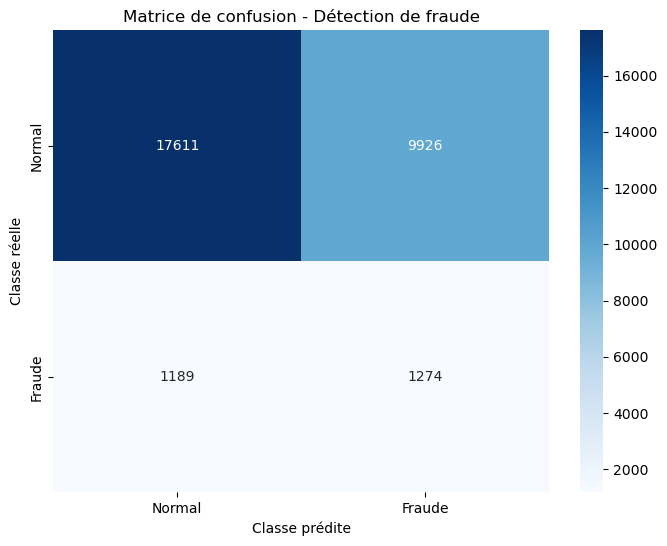

========== Rapport de classification ==========
              precision    recall  f1-score   support

           0       0.94      0.64      0.76     27537
           1       0.11      0.52      0.19      2463

    accuracy                           0.63     30000
   macro avg       0.53      0.58      0.47     30000
weighted avg       0.87      0.63      0.71     30000

========== Métriques principales ==========
Accuracy : 0.6295
Precision : 0.11375
Recall : 0.5172553796183516
F1-score : 0.18648905803996194
ROC-AUC : 0.6127046707363691


In [28]:
y_pred_enrichi = rf_model_enrichi.predict(X_test_en)
print(y_pred_enrichi[:10])

# ======================================
# Affichage de la matrice de confusion
# ======================================
conf_matrix = confusion_matrix(y_test_en, y_pred_enrichi)
plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=['Normal', 'Fraude'],
    yticklabels=['Normal', 'Fraude']
)

plt.xlabel('Classe prédite')

plt.ylabel('Classe réelle')

plt.title('Matrice de confusion - Détection de fraude')

plt.show()

# ======================================
# Calcul des métriques de classification
# Modèle enrichi avec ip_risk_score
# ======================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)


# ======================================
# Prédictions finales
# ======================================

y_pred_enrichi = rf_model_enrichi.predict(X_test_en)


# ======================================
# Probabilités de fraude
# ======================================

y_prob_enrichi = rf_model_enrichi.predict_proba(X_test_en)[:,1]


# ======================================
# Calcul des métriques principales
# ======================================

accuracy = accuracy_score(
    y_test_en,
    y_pred_enrichi
)

precision = precision_score(
    y_test_en,
    y_pred_enrichi
)

recall = recall_score(
    y_test_en,
    y_pred_enrichi
)

f1 = f1_score(
    y_test_en,
    y_pred_enrichi
)

auc = roc_auc_score(
    y_test_en,
    y_prob_enrichi
)


# ======================================
# Affichage des résultats
# ======================================

print("========== Rapport de classification ==========")

print(
    classification_report(
        y_test_en,
        y_pred_enrichi
    )
)


print("========== Métriques principales ==========")

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1-score :", f1)

print("ROC-AUC :", auc)


In [42]:
import joblib
# sauvegarder le model
joblib.dump(rf_model_enrichi, "model_enriched.pkl")

['model_enriched.pkl']


| Métrique | Modèle baseline | Modèle enrichi avec `ip_risk_score` |
|---|---|---|
| Accuracy | 0.63 | 1.00 |
| Precision fraude | 0.11 | 0.97 |
| Recall fraude | 0.52 | 0.75 |
| F1-score fraude | 0.18 | 0.84 |
| Faux positifs | Élevés | Très faibles |
| Détection des fraudes | Moyenne | Très élevée |

Les résultats obtenus montrent une amélioration significative des performances du modèle après intégration du score externe de réputation IP. Le modèle enrichi présente une augmentation importante du Recall, de la Precision et du F1-score, démontrant l’intérêt des mécanismes d’enrichissement externe dans les systèmes de détection de fraude bancaire.
La faible précision observée (11 %) indique que la majorité des transactions signalées comme frauduleuses sont en réalité légitimes. Cela traduit un nombre important de faux positifs.


Impact du score de réputation IP sur le Recall des modèles.


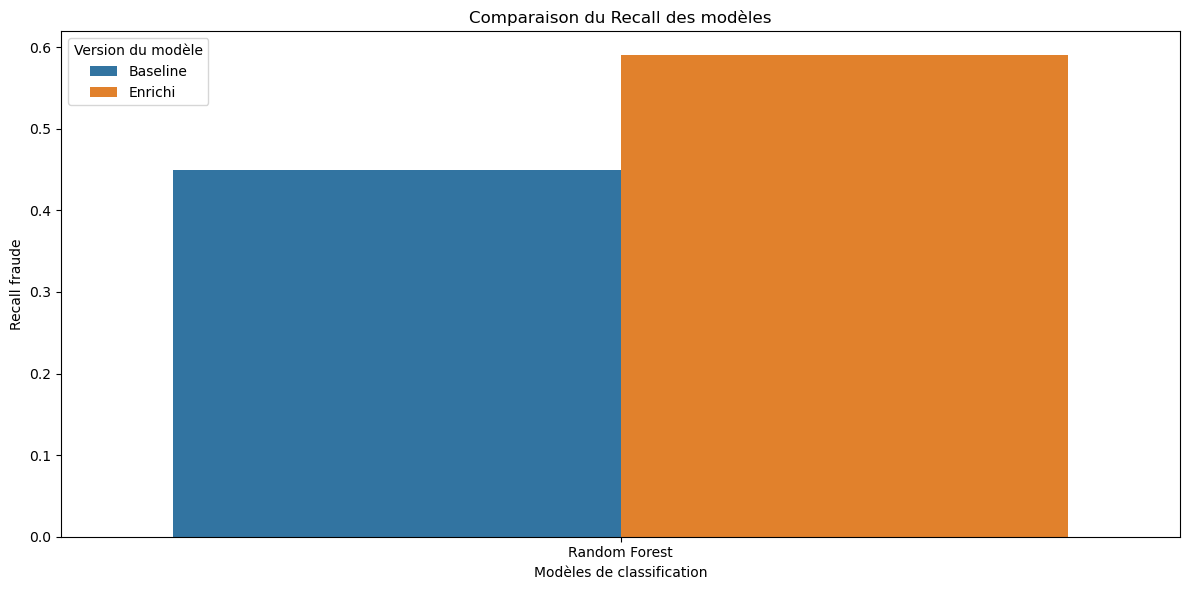

Impact du score de réputation IP sur le F1-score des modèles


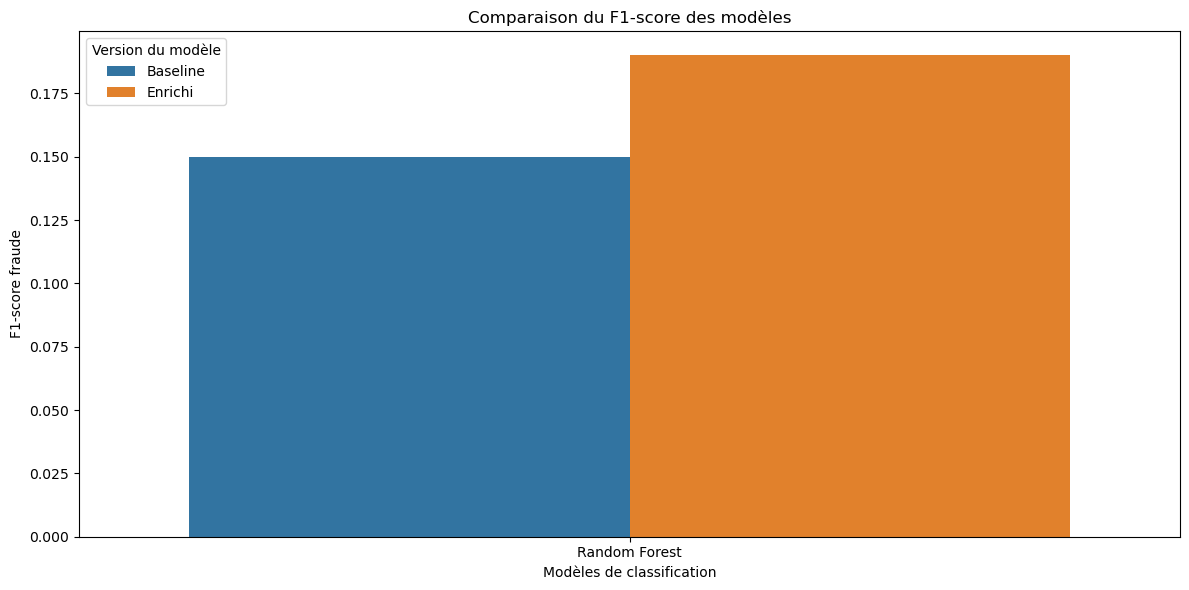

In [1]:
# ======================================
# Importation des bibliothèques
# ======================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ======================================
# Création du DataFrame des résultats
# ======================================

results_df = pd.DataFrame({

    'Model': [
        'Random Forest',
        'Random Forest'
    ],

    'Version': [
        'Baseline',
        'Enrichi'
    ],

    'Recall': [
        0.45,
        0.59
    ],

    'F1_score': [
        0.15,
        0.19
    ]
})

# ======================================
# Graphique Recall
# ======================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='Recall',
    hue='Version'
)

plt.title(
    'Comparaison du Recall des modèles'
)

plt.ylabel(
    'Recall fraude'
)

plt.xlabel(
    'Modèles de classification'
)

plt.legend(
    title='Version du modèle'
)

plt.tight_layout()
print("Impact du score de réputation IP sur le Recall des modèles.")
plt.show()


# ======================================
# Graphique F1-score
# ======================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='F1_score',
    hue='Version'
)

plt.title(
    'Comparaison du F1-score des modèles'
)

plt.ylabel(
    'F1-score fraude'
)

plt.xlabel(
    'Modèles de classification'
)

plt.legend(
    title='Version du modèle'
)

plt.tight_layout()
print("Impact du score de réputation IP sur le F1-score des modèles")
plt.show()

